# 🐱 Cat Breed Classifier
### Transfer Learning with EfficientNetV2S · 67 Cat Breeds

**Dataset**: [Cat Breeds — Kaggle](https://www.kaggle.com/datasets/nikolasgegenava/cat-breeds)  
**Goal**: Classify cat breed from a photo. Model exported as `.h5` for a Streamlit web app.

**Improvements in this version**:
- 🔥 **EfficientNetV2S** backbone (replaces MobileNetV2 — much stronger feature extractor)
- ✅ **Correct preprocessing** — `preprocess_input` instead of `/255` (was a bug)
- 💪 **Stronger head** — `Dense(512) → Dense(256)` with higher dropout
- 🎨 **More augmentation** — added `RandomTranslation`
- 🔓 **More fine-tuning** — top 80 layers unfrozen (was 30)

---
> ⚠️ **Before running**: Runtime → Change runtime type → **T4 GPU**

In [4]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU detected: {gpus[0].name}")
else:
    print("⚠️  No GPU found — go to Runtime > Change runtime type > T4 GPU")

✅ GPU detected: /physical_device:GPU:0


---
## 🔧 Section 1 — Setup & Installation

In [5]:
# Install kaggle API
!pip install kaggle -q
print("✅ kaggle installed")

✅ kaggle installed


In [6]:
# Mount Google Drive (model will be saved here — survives session resets)
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/cat_breed_classifier'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"📁 Save directory: {SAVE_DIR}")

Mounted at /content/drive
📁 Save directory: /content/drive/MyDrive/cat_breed_classifier


In [7]:
# ─── Paste your Kaggle API token here ─────────────────────────────────
# Go to kaggle.com → Settings → API → Create New Token
# Copy the token string (starts with KGAT_...) and paste below

import os

KAGGLE_TOKEN = 'KGAT_9740d09bffdde6753ab9223292ebc5e2'  # <-- your token

# Save token to the path kaggle CLI reads automatically
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(KAGGLE_TOKEN)
os.chmod('/root/.kaggle/access_token', 0o600)

# Quick test — should print dataset info without errors
!kaggle datasets list --max-size 1 -q 2>&1 | head -3
print("✅ Kaggle API token configured!")

usage: kaggle [-h] [-v] [-W]
              {competitions,c,datasets,d,kernels,k,models,m,files,f,benchmarks,b,config,auth} ...
kaggle: error: unrecognized arguments: -q
✅ Kaggle API token configured!


In [8]:
# Download and extract the Cat Breeds dataset
print("🐱 Downloading dataset (≈42 MB)...")
!kaggle datasets download -d nikolasgegenava/cat-breeds --force -q
!unzip -q cat-breeds.zip -d /content/cat-breeds
print("✅ Dataset ready at /content/cat-breeds")
!find /content/cat-breeds -maxdepth 3 -type d | head -20

🐱 Downloading dataset (≈42 MB)...
Dataset URL: https://www.kaggle.com/datasets/nikolasgegenava/cat-breeds
License(s): MIT
✅ Dataset ready at /content/cat-breeds
/content/cat-breeds
/content/cat-breeds/cat-breeds
/content/cat-breeds/cat-breeds/cat-breeds
/content/cat-breeds/cat-breeds/cat-breeds/chartreux
/content/cat-breeds/cat-breeds/cat-breeds/munchkin
/content/cat-breeds/cat-breeds/cat-breeds/american_wirehair
/content/cat-breeds/cat-breeds/cat-breeds/sphynx
/content/cat-breeds/cat-breeds/cat-breeds/bombay
/content/cat-breeds/cat-breeds/cat-breeds/serengeti
/content/cat-breeds/cat-breeds/cat-breeds/bengal
/content/cat-breeds/cat-breeds/cat-breeds/japanese_bobtail
/content/cat-breeds/cat-breeds/cat-breeds/turkish_angora
/content/cat-breeds/cat-breeds/cat-breeds/tonkinese
/content/cat-breeds/cat-breeds/cat-breeds/savannah
/content/cat-breeds/cat-breeds/cat-breeds/cornish_rex
/content/cat-breeds/cat-breeds/cat-breeds/russian_blue
/content/cat-breeds/cat-breeds/cat-breeds/norwegian_fore

In [9]:
# ─── All imports ───────────────────────────────────────────────────────
import os, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU detected: {bool(tf.config.list_physical_devices('GPU'))}")
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow  : 2.20.0
GPU detected: True


---
## 📂 Section 2 — Load & Organise Data

In [10]:
# ─── Scan dataset folders ──────────────────────────────────────────────
DATASET_ROOT = Path('/content/cat-breeds')
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

paths, labels = [], []

# Walk every subdirectory — collect images grouped by folder name (= breed)
for folder in sorted(DATASET_ROOT.rglob('*')):
    if folder.is_dir():
        imgs = [p for p in folder.iterdir() if p.suffix.lower() in IMG_EXTS]
        if imgs:
            breed = folder.name.lower()   # normalise to lowercase
            for img in imgs:
                paths.append(str(img))
                labels.append(breed)

df = pd.DataFrame({'path': paths, 'breed': labels})
print(f"✅ {len(df):,} images | {df['breed'].nunique()} breeds")
print(df['breed'].value_counts().to_string())

✅ 11,284 images | 66 breeds
breed
abyssinian              200
cyprus                  200
lykoi                   200
donskoy                 200
chausie                 200
european_shorthair      200
turkish_van             200
pixie_bob               200
ragdoll                 199
german_rex              199
american_shorthair      199
sokoke                  199
khao_manee              198
thai                    198
cymric                  198
oriental_shorthair      197
cornish_rex             197
burmese                 197
savannah                197
american_wirehair       196
peterbald               196
karelian_bobtail        196
tonkinese               195
balinese                195
japanese_bobtail        194
nebelung                194
selkirk_rex             192
persian                 192
manx                    192
himalayan               192
munchkin                191
bengal                  189
turkish_angora          188
vankedisi               187
scottish_fold 

In [11]:
# ─── Encode labels & split ─────────────────────────────────────────────
le = LabelEncoder()
df['label'] = le.fit_transform(df['breed'])
class_names = list(le.classes_)          # sorted alphabetically
NUM_CLASSES = len(class_names)
print(f"📋 {NUM_CLASSES} classes encoded")

# Stratified split so every breed appears in train / val / test
train_df, temp_df = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])

print(f"\n📊 Split sizes:")
print(f"  Train : {len(train_df):,} images ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val   : {len(val_df):,} images ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test  : {len(test_df):,} images ({len(test_df)/len(df)*100:.1f}%)")

📋 66 classes encoded

📊 Split sizes:
  Train : 9,027 images (80.0%)
  Val   : 1,128 images (10.0%)
  Test  : 1,129 images (10.0%)


In [12]:
# ─── Save class names to Drive ─────────────────────────────────────────
class_names_path = os.path.join(SAVE_DIR, 'class_names.json')
with open(class_names_path, 'w') as f:
    json.dump(class_names, f, indent=2)
print(f"✅ class_names.json saved → {class_names_path}")
print(f"   First 10: {class_names[:10]}")

✅ class_names.json saved → /content/drive/MyDrive/cat_breed_classifier/class_names.json
   First 10: ['abyssinian', 'american_bobtail', 'american_curl', 'american_shorthair', 'american_wirehair', 'balinese', 'bengal', 'birman', 'bombay', 'british_shorthair']


---
## 🔍 Section 3 — Explore the Data (EDA)

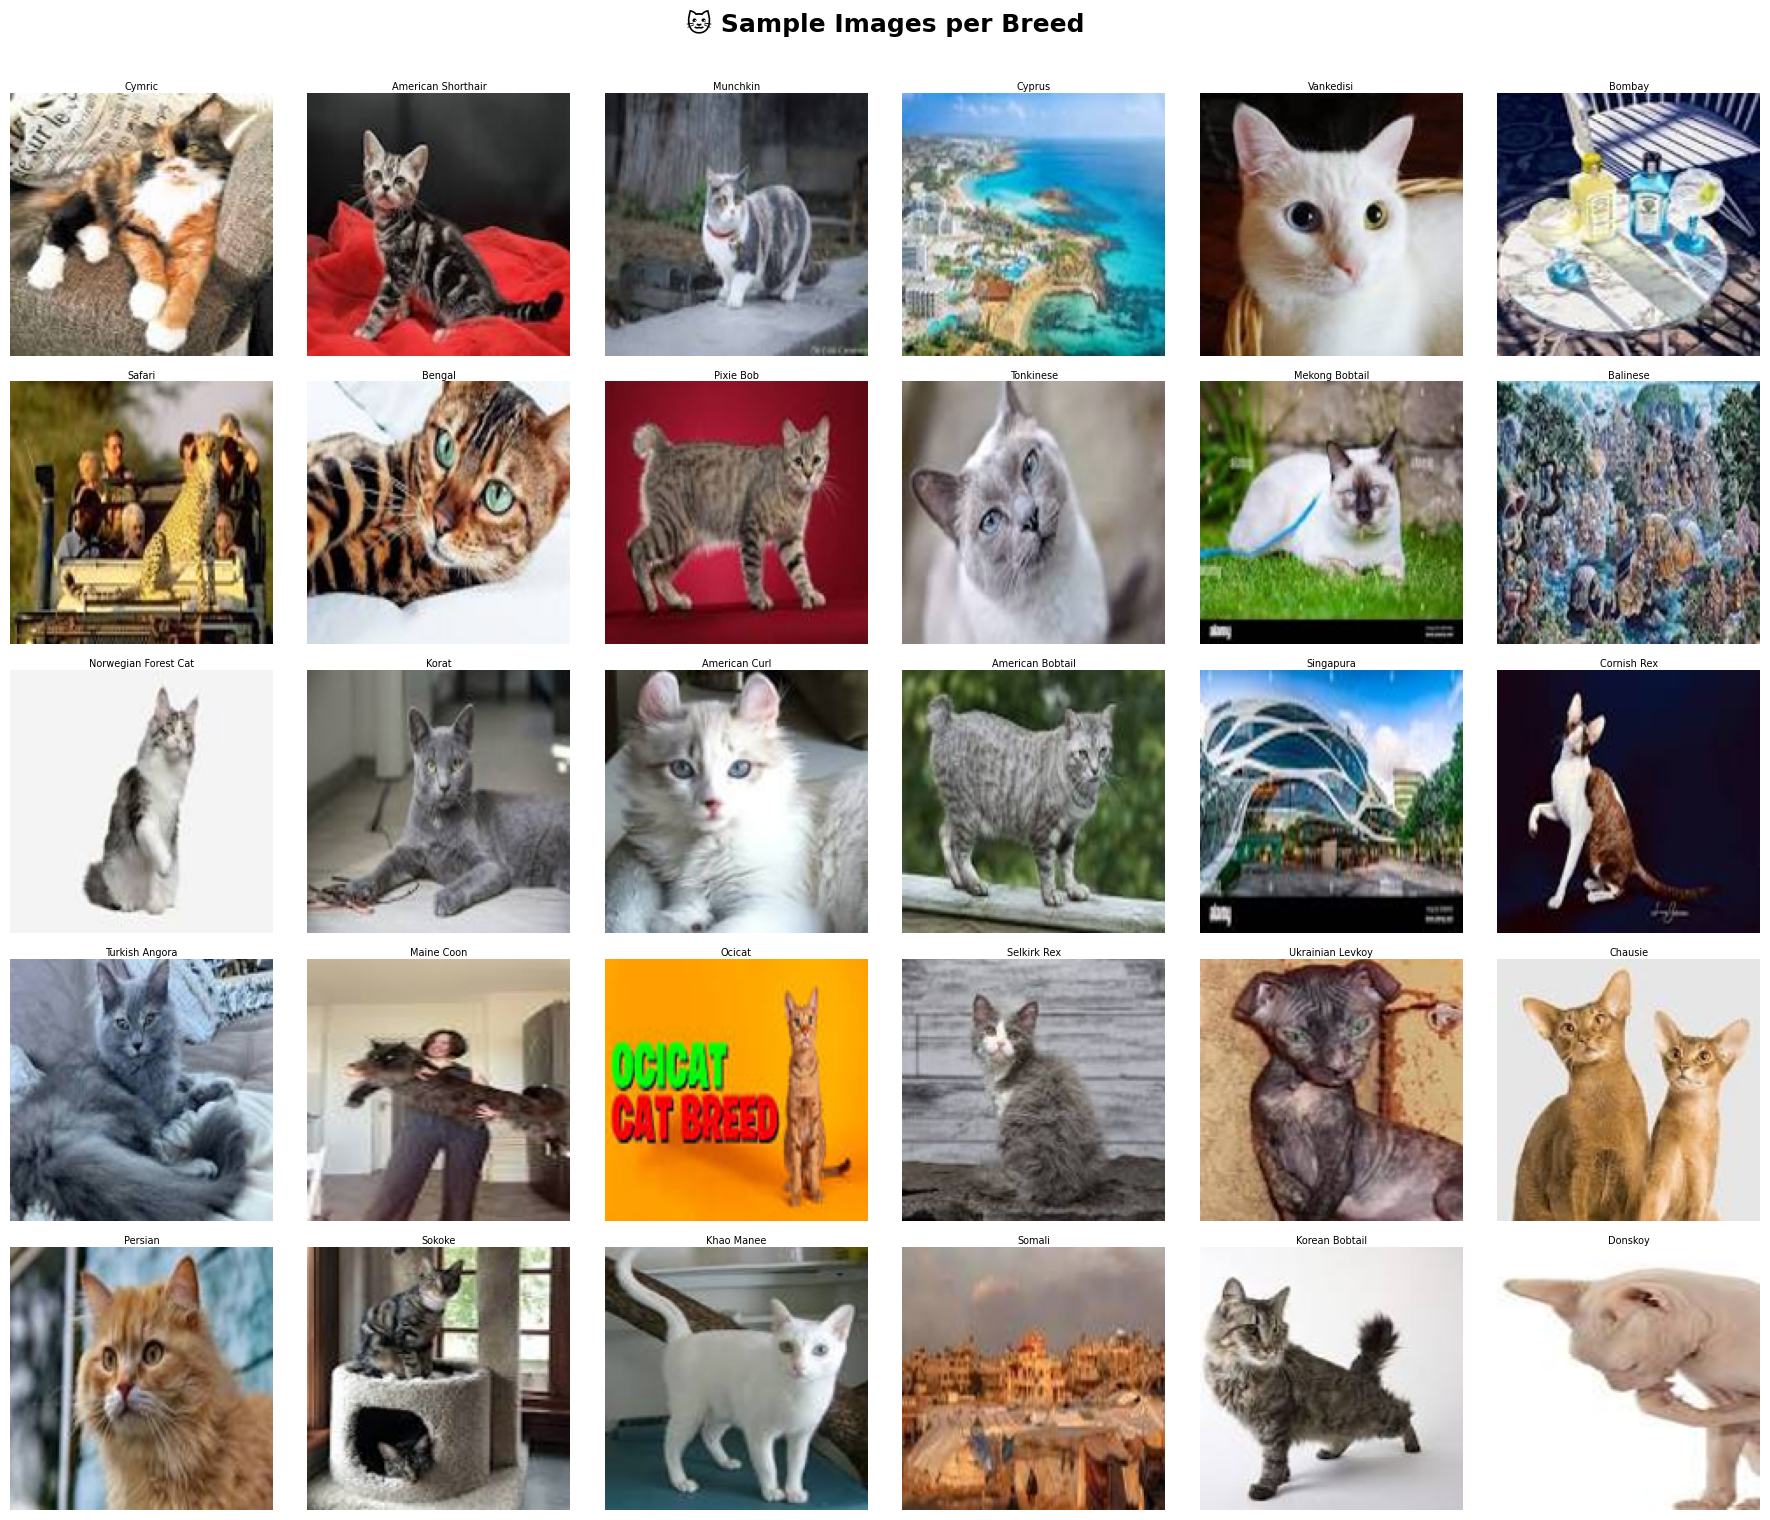

In [13]:
# ─── Sample images grid ────────────────────────────────────────────────
sample_breeds = random.sample(class_names, min(30, NUM_CLASSES))
fig, axes = plt.subplots(5, 6, figsize=(18, 15))
fig.suptitle('🐱 Sample Images per Breed', fontsize=18, fontweight='bold', y=1.01)

for ax, breed in zip(axes.flatten(), sample_breeds):
    row = df[df['breed'] == breed].sample(1).iloc[0]
    try:
        img = Image.open(row['path']).convert('RGB').resize((150, 150))
        ax.imshow(img)
    except Exception:
        ax.set_facecolor('#ddd')
    ax.set_title(breed.replace('_', ' ').title(), fontsize=7, pad=2)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'sample_breeds.png'), dpi=100, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3176/2530086622.py:17: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3176/2530086622.py:18: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, 'class_distribution.png'), dpi=100, bbox_inches='tight')
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


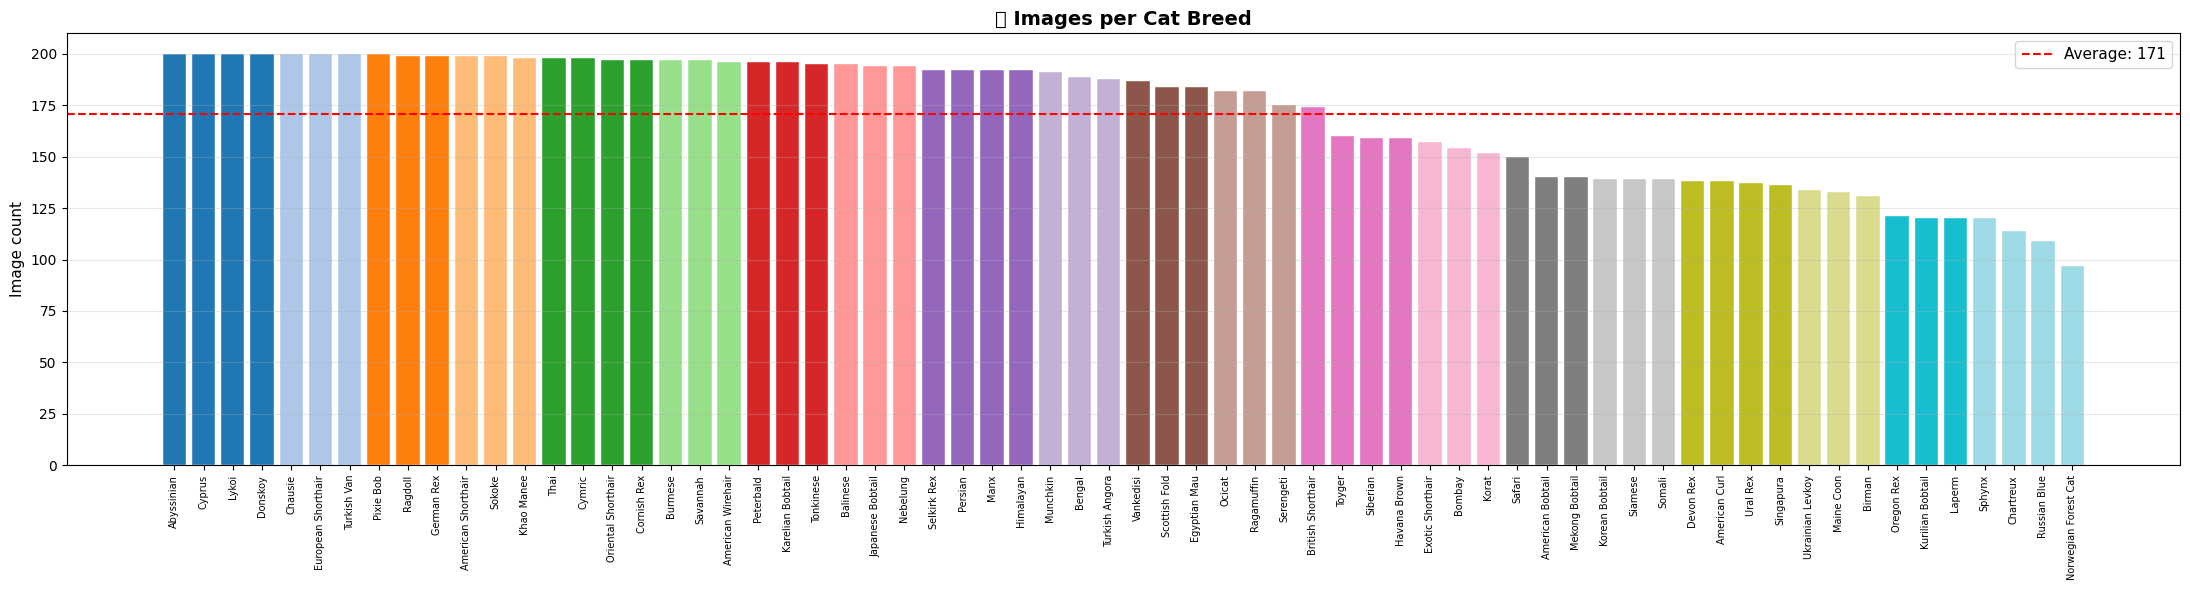

📈 Stats:
  Min  : 97 images  (norwegian_forest_cat)
  Max  : 200 images  (abyssinian)
  Mean : 171.0 images
  Total: 11,284 images


In [14]:
# ─── Class distribution ────────────────────────────────────────────────
counts = df['breed'].value_counts()
avg = counts.mean()

fig, ax = plt.subplots(figsize=(22, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(counts)))
ax.bar(range(len(counts)), counts.values, color=colors, edgecolor='white', linewidth=0.3)
ax.axhline(avg, color='red', linestyle='--', linewidth=1.5, label=f'Average: {avg:.0f}')
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(
    [b.replace('_', ' ').title() for b in counts.index],
    rotation=90, fontsize=7)
ax.set_ylabel('Image count', fontsize=11)
ax.set_title('📊 Images per Cat Breed', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'class_distribution.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f"📈 Stats:")
print(f"  Min  : {counts.min()} images  ({counts.idxmin()})")
print(f"  Max  : {counts.max()} images  ({counts.idxmax()})")
print(f"  Mean : {avg:.1f} images")
print(f"  Total: {counts.sum():,} images")

---
## 🧹 Section 4 — Preprocess & Data Augmentation

In [15]:
# ─── Config ────────────────────────────────────────────────────────────
IMG_SIZE   = 224   # EfficientNetV2S default input size
BATCH_SIZE = 32

# ─── Augmentation pipeline (applied ONLY during training) ──────────────
# Stronger augmentation helps with 67 fine-grained classes
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
    layers.RandomTranslation(0.10, 0.10),  # slight positional shift
], name='augmentation')

# ─── Image loader ──────────────────────────────────────────────────────
# NOTE: EfficientNetV2 expects pixel values in [0, 255] passed through
# preprocess_input (which scales to [-1, 1] internally).
# The previous /255.0 approach was incorrect for this backbone.
def load_image(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)   # ✅ correct scaling for EfficientNetV2
    return img, label

def make_dataset(dataframe, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (dataframe['path'].values, dataframe['label'].values))
    if shuffle:
        ds = ds.shuffle(len(dataframe), seed=42)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df, augment=True,  shuffle=True)
val_ds   = make_dataset(val_df,   augment=False, shuffle=False)
test_ds  = make_dataset(test_df,  augment=False, shuffle=False)

print("✅ tf.data pipelines created")
print(f"  Train batches : {len(train_ds)}")
print(f"  Val   batches : {len(val_ds)}")
print(f"  Test  batches : {len(test_ds)}")

✅ tf.data pipelines created
  Train batches : 283
  Val   batches : 36
  Test  batches : 36


/tmp/ipykernel_3176/1186277973.py:28: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


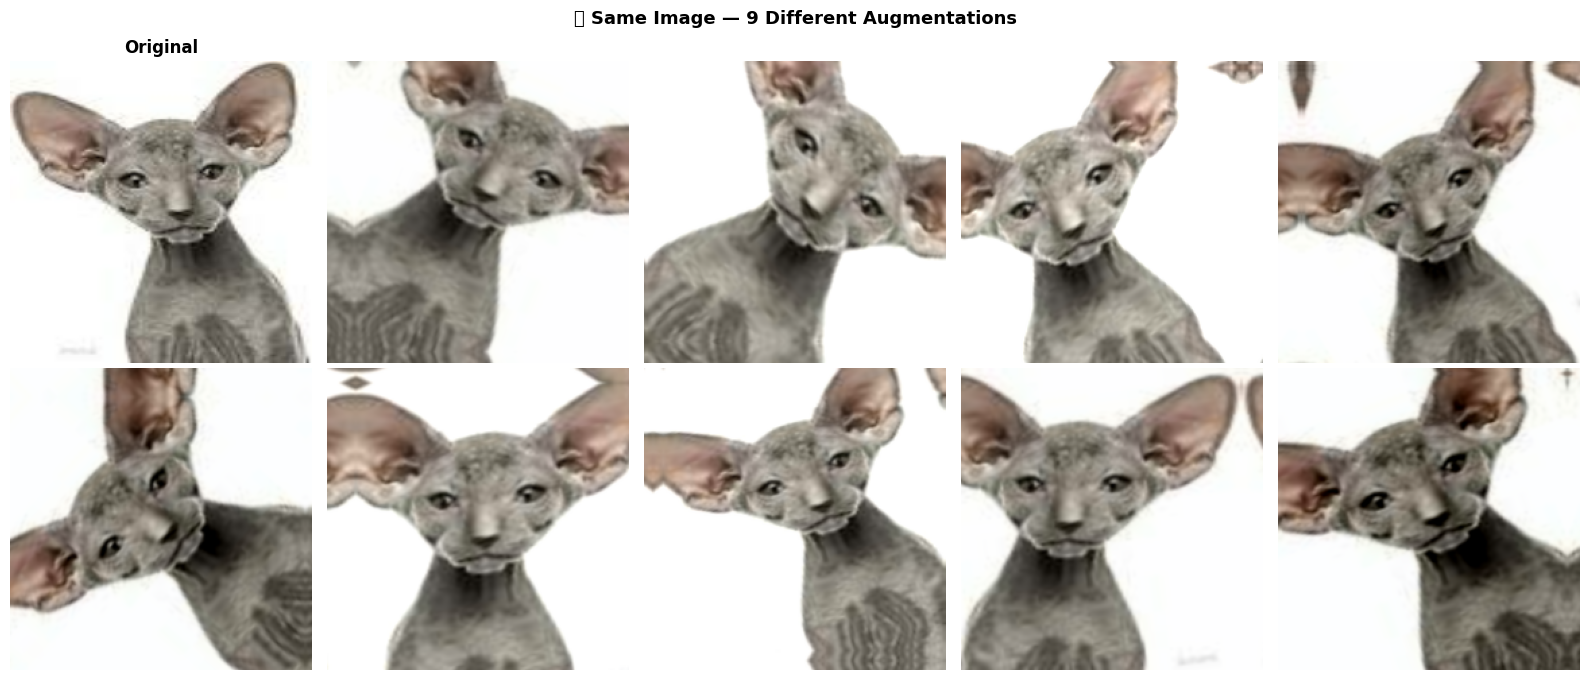

In [18]:
import tensorflow as tf
import matplotlib.pyplot as plt

# ─── Visualise augmentation ────────────────────────────────────────────
sample_path = train_df['path'].iloc[0]
raw = tf.io.read_file(sample_path)
img = tf.image.decode_image(raw, channels=3, expand_animations=False)
img = tf.cast(tf.image.resize(img, [IMG_SIZE, IMG_SIZE]), tf.float32)
img = preprocess_input(img)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('🎨 Same Image — 9 Different Augmentations', fontsize=13, fontweight='bold')

# Clip to [0,1] just for display (preprocess_input scales to ~[-1,1])
def to_display(t):
    t = (t - t.numpy().min()) / (t.numpy().max() - t.numpy().min() + 1e-7)
    return t.numpy()

axes[0, 0].imshow(to_display(img))
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

for ax in list(axes.flatten())[1:]:
    aug = data_augmentation(img, training=True)
    ax.imshow(to_display(aug))
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 🧠 Section 5 — Build the Model (Transfer Learning)

In [ ]:
# ─── EfficientNetV2S + stronger classification head ────────────────────
def build_model(num_classes: int, img_size: int = 224):
    # Pre-trained EfficientNetV2S — freeze all layers initially
    base = EfficientNetV2S(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)           # inference mode while frozen
    x = layers.GlobalAveragePooling2D()(x)     # flatten feature maps

    # Stronger head — two dense layers with batch norm + dropout
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base

model, base_model = build_model(NUM_CLASSES)
model.summary()

total   = model.count_params()
train_p = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen  = total - train_p
print(f"\n🔢 Total params   : {total:,}")
print(f"   Trainable      : {train_p:,}  (our new head)")
print(f"   Frozen         : {frozen:,}  (EfficientNetV2S base)")

In [ ]:
# ─── Compile (Phase 1 learning rate) ───────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_acc')
    ]
)
print("✅ Model compiled — ready for Phase 1 training")

---
## 🏋️ Section 6 — Two-Phase Training

| Phase | Base Model | Epochs | LR | Goal |
|---|---|---|---|---|
| **1** Feature Extraction | Frozen | 15 | 1e-3 | ~78–83% val acc |
| **2** Fine-Tuning | Top 80 layers unfrozen | 20 | 5e-6 | ~87–93% val acc |

In [ ]:
# ─── Phase 1 — Feature Extraction ─────────────────────────────────────
ckpt_p1 = os.path.join(SAVE_DIR, 'best_phase1.h5')

callbacks_p1 = [
    ModelCheckpoint(ckpt_p1, monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1),
]

print("🏋️  Phase 1 — base FROZEN, training top layers only...")
print("=" * 55)

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_p1,
    verbose=1
)

best_p1 = max(history_p1.history['val_accuracy'])
print(f"\n✅ Phase 1 complete!  Best val accuracy: {best_p1:.4f} ({best_p1*100:.2f}%)")

In [ ]:
# ─── Phase 2 — Fine-Tuning ─────────────────────────────────────────────
# Unfreeze the last 80 layers of EfficientNetV2S
# (EfficientNetV2S has ~450 layers, top-80 covers the last few blocks)
base_model.trainable = True
for layer in base_model.layers[:-80]:
    layer.trainable = False

n_trainable = sum(1 for l in base_model.layers if l.trainable)
print(f"🔓 Unfrozen {n_trainable} layers in EfficientNetV2S base")
print(f"   Trainable params now: {model.count_params():,}")

# Re-compile with a very small LR — large backbone needs gentle updates
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-6),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_acc')
    ]
)

ckpt_final = os.path.join(SAVE_DIR, 'best_model_final.h5')

callbacks_p2 = [
    ModelCheckpoint(ckpt_final, monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-9, verbose=1),
]

print("\n🏋️  Phase 2 — fine-tuning top 80 base layers...")
print("=" * 55)

history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_p2,
    verbose=1
)

best_p2 = max(history_p2.history['val_accuracy'])
print(f"\n✅ Phase 2 complete!  Best val accuracy: {best_p2:.4f} ({best_p2*100:.2f}%)")

---
## 📊 Section 7 — Evaluate the Model

In [ ]:
# ─── Training history plot ─────────────────────────────────────────────
def plot_history(h1, h2):
    acc     = h1.history['accuracy']     + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss    = h1.history['loss']         + h2.history['loss']
    val_loss= h1.history['val_loss']     + h2.history['val_loss']
    split   = len(h1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('Training History (Phase 1 + Phase 2)', fontsize=14, fontweight='bold')

    for ax, train, val, title, ylabel in [
        (ax1, acc, val_acc, 'Accuracy', 'Accuracy'),
        (ax2, loss, val_loss, 'Loss', 'Loss'),
    ]:
        ax.plot(train, label='Train', color='royalblue', linewidth=2)
        ax.plot(val,   label='Validation', color='darkorange', linewidth=2)
        ax.axvline(split, color='crimson', linestyle='--', linewidth=1.5,
                   label=f'Fine-tuning starts (epoch {split})')
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'training_history.png'), dpi=100, bbox_inches='tight')
    plt.show()

plot_history(history_p1, history_p2)

In [ ]:
# ─── Test set evaluation ───────────────────────────────────────────────
print("📊 Evaluating on TEST set (never seen during training)...")
test_loss, test_acc, test_top3 = model.evaluate(test_ds, verbose=0)

print(f"\n{'='*40}")
print(f"  Top-1 Accuracy : {test_acc*100:.2f}%")
print(f"  Top-3 Accuracy : {test_top3*100:.2f}%")
print(f"  Loss           : {test_loss:.4f}")
print(f"{'='*40}")

In [ ]:
# ─── Per-breed classification report ───────────────────────────────────
print("📋 Generating classification report...")

y_true, y_pred = [], []
for images, labels_batch in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels_batch.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true_names = [class_names[i] for i in y_true]
y_pred_names = [class_names[i] for i in y_pred]

print(classification_report(y_true_names, y_pred_names, zero_division=0))

In [ ]:
# ─── Confusion matrix (top 20 most-confused breeds) ───────────────────
cm = confusion_matrix(y_true, y_pred)

# Select 20 breeds with most prediction errors for readable plot
errors = cm.sum(axis=1) - np.diag(cm)
top20  = np.argsort(errors)[-20:][::-1]
cm_sub = cm[np.ix_(top20, top20)]
labels_sub = [class_names[i].replace('_', '\n').title() for i in top20]

plt.figure(figsize=(16, 13))
sns.heatmap(cm_sub, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_sub, yticklabels=labels_sub,
            linewidths=0.4, linecolor='white')
plt.title('Confusion Matrix — Top 20 Most Confused Breeds', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7, rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# ─── Visual prediction samples ─────────────────────────────────────────
def show_predictions(dataframe, n=12):
    sample = dataframe.sample(n, random_state=7)
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle('Sample Predictions on Test Set', fontsize=14, fontweight='bold')

    for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
        try:
            img_pil = Image.open(row['path']).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        except Exception:
            ax.axis('off')
            continue

        arr = np.array(img_pil, dtype=np.float32)
        arr = preprocess_input(arr)            # ✅ must match training
        pred    = model.predict(arr[np.newaxis], verbose=0)[0]
        top1_idx  = np.argmax(pred)
        top1_conf = pred[top1_idx]
        true_name = class_names[row['label']]
        pred_name = class_names[top1_idx]
        correct   = (top1_idx == row['label'])

        ax.imshow(img_pil)                     # display original PIL (RGB)
        ax.set_title(
            f"True: {true_name.replace('_',' ').title()}\n"
            f"Pred: {pred_name.replace('_',' ').title()} ({top1_conf*100:.1f}%)",
            fontsize=7,
            color='green' if correct else 'red'
        )
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'sample_predictions.png'), dpi=100, bbox_inches='tight')
    plt.show()

show_predictions(test_df)

---
## 💾 Section 8 — Save Model & Prediction Function

In [ ]:
# ─── Breed info cards ───────────────────────────────────────────────────
# Used by the Streamlit web app to show fun facts after prediction
BREED_INFO = {
    "abyssinian":          {"origin": "Ethiopia", "lifespan": "9–15 yrs", "temperament": "Active, Curious, Playful, Intelligent", "fun_fact": "Often depicted in ancient Egyptian art — one of the oldest known breeds."},
    "american_bobtail":    {"origin": "United States", "lifespan": "11–15 yrs", "temperament": "Friendly, Intelligent, Adaptable", "fun_fact": "They love to play fetch — very dog-like personality!"},
    "american_curl":       {"origin": "United States", "lifespan": "12–16 yrs", "temperament": "Affectionate, Social, Gentle", "fun_fact": "Born with straight ears that curl backward within days of birth."},
    "american_shorthair":  {"origin": "United States", "lifespan": "15–20 yrs", "temperament": "Easygoing, Adaptable, Gentle", "fun_fact": "One of the most popular cat breeds in the USA, descended from working cats."},
    "american_wirehair":   {"origin": "United States", "lifespan": "14–18 yrs", "temperament": "Adaptable, Affectionate, Playful", "fun_fact": "Their unique wiry coat is a natural mutation first seen in 1966."},
    "balinese":            {"origin": "United States", "lifespan": "12–20 yrs", "temperament": "Vocal, Intelligent, Affectionate", "fun_fact": "Sometimes called the 'long-haired Siamese' — same vocal personality!"},
    "bengal":              {"origin": "United States", "lifespan": "12–16 yrs", "temperament": "Active, Energetic, Curious, Playful", "fun_fact": "Descended from Asian Leopard Cats — wild look, domestic heart."},
    "birman":              {"origin": "Burma (Myanmar)", "lifespan": "12–16 yrs", "temperament": "Gentle, Affectionate, Social", "fun_fact": "Legend says Birmans were sacred temple cats blessed by a golden goddess."},
    "bombay":              {"origin": "United States", "lifespan": "12–18 yrs", "temperament": "Affectionate, Playful, Social", "fun_fact": "Bred to look like a miniature black panther — nicknamed 'parlor panther'."},
    "british_shorthair":   {"origin": "United Kingdom", "lifespan": "12–20 yrs", "temperament": "Calm, Easygoing, Affectionate", "fun_fact": "The Cheshire Cat from Alice in Wonderland was inspired by this breed!"},
    "burmese":             {"origin": "Burma (Myanmar)", "lifespan": "16–18 yrs", "temperament": "Social, Affectionate, Energetic", "fun_fact": "All Burmese worldwide trace back to a single female cat brought to the USA in 1930."},
    "chartreux":           {"origin": "France", "lifespan": "11–15 yrs", "temperament": "Quiet, Gentle, Loyal, Playful", "fun_fact": "French monks at the Grande Chartreuse monastery are said to have bred this cat."},
    "chausie":             {"origin": "United States", "lifespan": "12–14 yrs", "temperament": "Active, Loyal, Intelligent", "fun_fact": "Descended from the Jungle Cat (Felis chaus) — one of the closest to wild cats."},
    "cornish_rex":         {"origin": "Cornwall, UK", "lifespan": "11–15 yrs", "temperament": "Active, Playful, Sociable, Mischievous", "fun_fact": "Has only the soft undercoat — no guard hairs, giving a uniquely curly look."},
    "cymric":              {"origin": "Canada / Isle of Man", "lifespan": "8–14 yrs", "temperament": "Gentle, Playful, Intelligent", "fun_fact": "Essentially a long-haired Manx — they share the taillessness gene."},
    "cyprus":              {"origin": "Cyprus", "lifespan": "12–15 yrs", "temperament": "Adaptable, Friendly, Independent", "fun_fact": "One of the oldest domesticated cat breeds — evidence dates back 9,500 years!"},
    "devon_rex":           {"origin": "Devon, UK", "lifespan": "9–15 yrs", "temperament": "Mischievous, Playful, People-oriented", "fun_fact": "Called 'pixie cats' due to their large ears and elfin face."},
    "donskoy":             {"origin": "Russia", "lifespan": "12–15 yrs", "temperament": "Affectionate, Loyal, Curious", "fun_fact": "Hairlessness is caused by a dominant gene — unlike Sphynx which is recessive."},
    "egyptian_mau":        {"origin": "Egypt", "lifespan": "12–15 yrs", "temperament": "Active, Loyal, Playful", "fun_fact": "The only naturally spotted domestic cat breed — spots are in the coat, not just the skin!"},
    "european_shorthair":  {"origin": "Europe", "lifespan": "15–20 yrs", "temperament": "Adaptable, Playful, Independent", "fun_fact": "The most common cat in Europe, descended from cats the Romans spread across the continent."},
    "exotic_shorthair":    {"origin": "United States", "lifespan": "12–15 yrs", "temperament": "Calm, Gentle, Playful, Affectionate", "fun_fact": "Nicknamed 'the lazy man's Persian' — same look, easier-to-maintain coat."},
    "german_rex":          {"origin": "Germany", "lifespan": "12–15 yrs", "temperament": "Affectionate, Playful, Curious, Social", "fun_fact": "One of the first curly-coated breeds, discovered in Germany after World War II."},
    "havana_brown":        {"origin": "United Kingdom", "lifespan": "10–15 yrs", "temperament": "Affectionate, Curious, Playful, Social", "fun_fact": "The only all-brown cat breed — their rich mahogany color inspired the name 'Havana'."},
    "himalayan":           {"origin": "United States", "lifespan": "9–15 yrs", "temperament": "Calm, Gentle, Sweet, Quiet", "fun_fact": "A Persian × Siamese cross — Persian body with Siamese color points."},
    "japanese_bobtail":    {"origin": "Japan", "lifespan": "15–18 yrs", "temperament": "Active, Vocal, Sociable, Friendly", "fun_fact": "The 'Maneki-neko' lucky waving cat figurine is modeled after this breed!"},
    "karelian_bobtail":    {"origin": "Russia / Finland", "lifespan": "12–15 yrs", "temperament": "Calm, Friendly, Adaptable", "fun_fact": "A rare natural breed from Karelian forests with a pom-pom tail."},
    "khao_manee":          {"origin": "Thailand", "lifespan": "10–12 yrs", "temperament": "Curious, Playful, Affectionate, Social", "fun_fact": "An ancient Thai royal cat — once exclusive to royalty."},
    "korat":               {"origin": "Thailand", "lifespan": "15+ yrs", "temperament": "Gentle, Loyal, Playful, Affectionate", "fun_fact": "In Thailand, Korats are considered good luck and gifted to newlyweds."},
    "korean_bobtail":      {"origin": "Korea", "lifespan": "10–14 yrs", "temperament": "Active, Curious, Friendly, Independent", "fun_fact": "A natural breed from Korea with a distinctive short, pom-pom tail."},
    "kurilian_bobtail":    {"origin": "Russia (Kuril Islands)", "lifespan": "15–20 yrs", "temperament": "Gentle, Social, Playful, Adaptable", "fun_fact": "Natural hunters from the remote Kuril Islands — excellent fishers!"},
    "laperm":              {"origin": "United States", "lifespan": "10–15 yrs", "temperament": "Affectionate, Gentle, Curious, Active", "fun_fact": "Born bald, they grow a unique curly coat — each cat's curls are different!"},
    "lykoi":               {"origin": "United States", "lifespan": "12–15 yrs", "temperament": "Loyal, Playful, Friendly, Curious", "fun_fact": "Called the 'Werewolf Cat' — their patchy coat gives a spooky, Halloween appearance."},
    "maine_coon":          {"origin": "United States (Maine)", "lifespan": "12–15 yrs", "temperament": "Friendly, Playful, Gentle, Dog-like", "fun_fact": "The largest domestic cat breed — males can reach 18 lbs! They love water."},
    "manx":                {"origin": "Isle of Man", "lifespan": "14–16 yrs", "temperament": "Gentle, Playful, Social, Loyal", "fun_fact": "Naturally tailless due to a genetic mutation — can be fully tailless or have a stub."},
    "mekong_bobtail":      {"origin": "Southeast Asia", "lifespan": "12–15 yrs", "temperament": "Affectionate, Loyal, Social, Gentle", "fun_fact": "Named after the Mekong River — historically kept by royalty across Southeast Asia."},
    "munchkin":            {"origin": "United States", "lifespan": "12–15 yrs", "temperament": "Playful, Outgoing, Affectionate, Curious", "fun_fact": "Their short legs are a natural mutation — they can still run surprisingly fast!"},
    "nebelung":            {"origin": "United States", "lifespan": "15–18 yrs", "temperament": "Gentle, Shy, Loyal, Affectionate", "fun_fact": "Named after German mythology ('creature of the mist') — their shimmery coat inspired it."},
    "norwegian_forest_cat":{"origin": "Norway", "lifespan": "12–16 yrs", "temperament": "Independent, Gentle, Adventurous", "fun_fact": "Vikings likely kept these cats on ships to catch mice during long voyages!"},
    "ocicat":              {"origin": "United States", "lifespan": "12–18 yrs", "temperament": "Active, Sociable, Curious, Playful", "fun_fact": "Looks wild but is entirely domestic — created by accident from Siamese × Abyssinian crosses."},
    "oregon_rex":          {"origin": "United States (Oregon)", "lifespan": "12–15 yrs", "temperament": "Playful, Affectionate, Gentle, Social", "fun_fact": "An extremely rare curly-coated breed — now considered an extinct separate variety."},
    "oriental_shorthair":  {"origin": "United Kingdom", "lifespan": "12–15 yrs", "temperament": "Vocal, Sociable, Affectionate, Demanding", "fun_fact": "Comes in over 300 color and pattern combinations — more than any other breed!"},
    "persian":             {"origin": "Iran (Persia)", "lifespan": "12–17 yrs", "temperament": "Gentle, Quiet, Calm, Affectionate", "fun_fact": "Their luxurious coat can grow up to 6 inches long and needs daily brushing."},
    "peterbald":           {"origin": "Russia (St. Petersburg)", "lifespan": "12–15 yrs", "temperament": "Affectionate, Curious, Energetic, Social", "fun_fact": "Created in 1994 by crossing a Donskoy with an Oriental Shorthair."},
    "pixie_bob":           {"origin": "United States", "lifespan": "13–15 yrs", "temperament": "Sociable, Loyal, Gentle, Dog-like", "fun_fact": "Rumored to descend from bobcats — DNA tests show they are fully domestic."},
    "ragamuffin":          {"origin": "United States", "lifespan": "12–16 yrs", "temperament": "Gentle, Calm, Affectionate, Patient", "fun_fact": "They go completely limp when held — nicknamed 'puppy cats'."},
    "ragdoll":             {"origin": "United States", "lifespan": "12–17 yrs", "temperament": "Gentle, Relaxed, Affectionate, Calm", "fun_fact": "Named 'Ragdoll' because they go limp and floppy when you pick them up!"},
    "russian_blue":        {"origin": "Russia", "lifespan": "15–20 yrs", "temperament": "Gentle, Reserved, Loyal, Intelligent", "fun_fact": "Their double coat has silver-tipped guard hairs giving a shimmering blue glow."},
    "safari":              {"origin": "United States", "lifespan": "12–16 yrs", "temperament": "Active, Curious, Affectionate, Energetic", "fun_fact": "A rare hybrid from domestic cats × wild Geoffroy's Cat from South America."},
    "savannah":            {"origin": "United States", "lifespan": "12–20 yrs", "temperament": "Active, Adventurous, Loyal, Curious", "fun_fact": "The tallest domestic cat — crossed with Serval, they can jump over 8 feet high!"},
    "scottish_fold":       {"origin": "Scotland", "lifespan": "11–14 yrs", "temperament": "Adaptable, Sweet, Calm, Gentle", "fun_fact": "All Scottish Folds trace back to one barn cat named Susie, found in Scotland in 1961."},
    "selkirk_rex":         {"origin": "United States", "lifespan": "14–15 yrs", "temperament": "Tolerant, Loving, Playful, Patient", "fun_fact": "Named after the Selkirk Mountains — the only curly-coated breed named after a person!"},
    "serengeti":           {"origin": "United States", "lifespan": "10–15 yrs", "temperament": "Active, Vocal, Sociable, Energetic", "fun_fact": "Bred to look like a Serval — from Bengal × Oriental Shorthair crosses, no wild blood."},
    "siberian":            {"origin": "Russia", "lifespan": "11–18 yrs", "temperament": "Playful, Affectionate, Adventurous, Loyal", "fun_fact": "Russia's national cat — centuries-old forest breed, and semi-hypoallergenic!"},
    "singapura":           {"origin": "Singapore", "lifespan": "11–15 yrs", "temperament": "Curious, Playful, Affectionate, Sociable", "fun_fact": "The smallest domestic cat breed — adults weigh only 4–8 pounds!"},
    "sokoke":              {"origin": "Kenya", "lifespan": "9–15 yrs", "temperament": "Active, Sociable, Intelligent, Dog-like", "fun_fact": "One of the rarest breeds — discovered living wild in Kenya's Arabuko-Sokoke Forest."},
    "somali":              {"origin": "United States / Canada", "lifespan": "12–16 yrs", "temperament": "Active, Curious, Playful, Sociable", "fun_fact": "Called the 'fox cat' — essentially a long-haired Abyssinian with a fluffy tail."},
    "sphynx":              {"origin": "Canada", "lifespan": "8–14 yrs", "temperament": "Energetic, Mischievous, Warm, Social", "fun_fact": "Despite looking hairless, they're covered in fine peach-fuzz and feel like warm suede!"},
    "thai":                {"origin": "Thailand", "lifespan": "12–16 yrs", "temperament": "Vocal, Social, Intelligent, Curious", "fun_fact": "The traditional round-faced Siamese, preserved by Thai cat fanciers."},
    "tonkinese":           {"origin": "Canada", "lifespan": "14–16 yrs", "temperament": "Playful, Social, Affectionate, Vocal", "fun_fact": "A Siamese × Burmese cross — they inherited the best traits of both!"},
    "toyger":              {"origin": "United States", "lifespan": "10–15 yrs", "temperament": "Relaxed, Friendly, Intelligent, Easygoing", "fun_fact": "Bred to look like a miniature tiger — 'Toyger' = 'Toy Tiger'. Still being developed!"},
    "turkish_angora":      {"origin": "Turkey (Ankara)", "lifespan": "12–18 yrs", "temperament": "Playful, Affectionate, Intelligent, Energetic", "fun_fact": "The Ankara Zoo has a special program to preserve this ancient Turkish breed."},
    "turkish_van":         {"origin": "Turkey (Lake Van)", "lifespan": "12–17 yrs", "temperament": "Active, Playful, Independent, Affectionate", "fun_fact": "Known as 'the swimming cat' — they genuinely love water and are strong swimmers!"},
    "ukrainian_levkoy":    {"origin": "Ukraine", "lifespan": "12–15 yrs", "temperament": "Gentle, Sociable, Curious, Playful", "fun_fact": "Created in Ukraine in 2004 — a Donskoy × Scottish Fold cross with folded ears and no fur."},
    "ural_rex":            {"origin": "Russia (Ural Mountains)", "lifespan": "12–15 yrs", "temperament": "Gentle, Calm, Sociable, Loyal", "fun_fact": "A natural curly breed from the Ural Mountains, independently evolved from other Rex breeds."},
    "vankedisi":           {"origin": "Turkey", "lifespan": "12–17 yrs", "temperament": "Playful, Active, Independent, Curious", "fun_fact": "The all-white version of the Turkish Van — 'Vankedisi' means 'Van cat' in Turkish."},
}

# Save to Drive for use in web app
breed_info_path = os.path.join(SAVE_DIR, 'breed_info.json')
with open(breed_info_path, 'w', encoding='utf-8') as f:
    json.dump(BREED_INFO, f, indent=2, ensure_ascii=False)

print(f"✅ breed_info.json saved → {breed_info_path}")
print(f"   Covers {len(BREED_INFO)} breeds")

In [ ]:
# ─── Save final model ──────────────────────────────────────────────────
final_model_path = os.path.join(SAVE_DIR, 'cat_breed_model.h5')
model.save(final_model_path)
print(f"✅ Model saved → {final_model_path}")

# Verify we can reload it
model_reloaded = keras.models.load_model(final_model_path)
loss, acc, top3 = model_reloaded.evaluate(test_ds, verbose=0)
print(f"\n🔍 Reload check — Test accuracy: {acc*100:.2f}%  Top-3: {top3*100:.2f}%")

# List all saved files
print("\n📁 Files saved to Google Drive:")
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(os.path.join(SAVE_DIR, f))
    print(f"   {f:40s}  {size/1e6:.1f} MB")

In [ ]:
# ─── Prediction function (copy this into your Streamlit app) ──────────
import numpy as np
from PIL import Image
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as eff_preprocess

def predict_breed(image_input, model, class_names, breed_info, top_k=3):
    """
    Predict cat breed from an image.

    Args:
        image_input : PIL.Image or file path (str)
        model       : loaded Keras model
        class_names : list of breed names (from class_names.json)
        breed_info  : dict of breed details (from breed_info.json)
        top_k       : number of top predictions to return

    Returns:
        list of dicts with keys: breed, confidence, origin, lifespan,
                                  temperament, fun_fact
    """
    if isinstance(image_input, str):
        img = Image.open(image_input).convert('RGB')
    else:
        img = image_input.convert('RGB')

    img = img.resize((224, 224))
    arr = np.array(img, dtype=np.float32)
    arr = eff_preprocess(arr)          # ✅ must match training preprocessing
    arr = np.expand_dims(arr, axis=0)

    probs    = model.predict(arr, verbose=0)[0]
    top_idx  = np.argsort(probs)[::-1][:top_k]

    results = []
    for idx in top_idx:
        breed = class_names[idx]
        info  = breed_info.get(breed, {})
        results.append({
            'breed':        breed.replace('_', ' ').title(),
            'confidence':   float(probs[idx]),
            'origin':       info.get('origin', 'Unknown'),
            'lifespan':     info.get('lifespan', 'Unknown'),
            'temperament':  info.get('temperament', 'Unknown'),
            'fun_fact':     info.get('fun_fact', ''),
        })

    return results


# Quick demo
demo_path = test_df['path'].iloc[0]
demo_img  = Image.open(demo_path)
true_name = class_names[test_df['label'].iloc[0]]

results = predict_breed(demo_img, model, class_names, BREED_INFO, top_k=3)

print(f"🐱 True breed : {true_name.replace('_',' ').title()}")
print(f"\n📊 Top-3 Predictions:")
print(f"{'Rank':<6} {'Breed':<30} {'Confidence':<12} {'Origin'}")
print('-' * 70)
for i, r in enumerate(results, 1):
    print(f"#{i:<5} {r['breed']:<30} {r['confidence']*100:>7.2f}%    {r['origin']}")

print(f"\n💡 Fun Fact: {results[0]['fun_fact']}")

In [ ]:
# ─── Show image + prediction card ──────────────────────────────────────
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('🐱 Prediction Result', fontsize=15, fontweight='bold')

# Image
demo_img_display = Image.open(demo_path).convert('RGB').resize((300, 300))
ax_img.imshow(demo_img_display)
ax_img.set_title(f'True: {true_name.replace(chr(95)," ").title()}', fontsize=11)
ax_img.axis('off')

# Confidence bars
breeds = [r['breed'] for r in results]
confs  = [r['confidence'] * 100 for r in results]
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = ax_bar.barh(range(len(results))[::-1], confs, color=colors, height=0.5, edgecolor='white')
ax_bar.set_yticks(range(len(results))[::-1])
ax_bar.set_yticklabels(breeds, fontsize=11)
ax_bar.set_xlabel('Confidence (%)', fontsize=11)
ax_bar.set_title('Top-3 Predictions', fontsize=12)
ax_bar.set_xlim(0, 100)
ax_bar.grid(axis='x', alpha=0.3)

for bar, conf in zip(bars, confs):
    ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{conf:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'demo_prediction.png'), dpi=100, bbox_inches='tight')
plt.show()

---
## 🎉 Done! Files saved to Google Drive

| File | Used for |
|---|---|
| `cat_breed_model.h5` | Load in Streamlit web app |
| `class_names.json` | Map model output → breed name |
| `breed_info.json` | Show breed info cards in the app |
| `training_history.png` | Training curves |
| `confusion_matrix.png` | Where the model struggles |

### ➡️ Next step: Build the Streamlit web app!